# Week 01 - Task 02
## Clean & Visualize Real-World Data (Titanic Dataset)

**Objective:** Clean missing data, detect outliers, visualize patterns, and understand the dataset before machine learning.

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Import Libraries

We use pandas and NumPy for data handling, while matplotlib and seaborn are used for data visualization.

In [3]:
df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Missing Values

The dataset contains missing values in Age, Cabin, and Embarked.

In [5]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=["Cabin"], inplace=True)

### Missing Values

Age was filled using the median because it is a numerical column.

Embarked was filled using the mode because it is categorical.

Cabin was dropped because most of its values were missing.

In [6]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Histogram

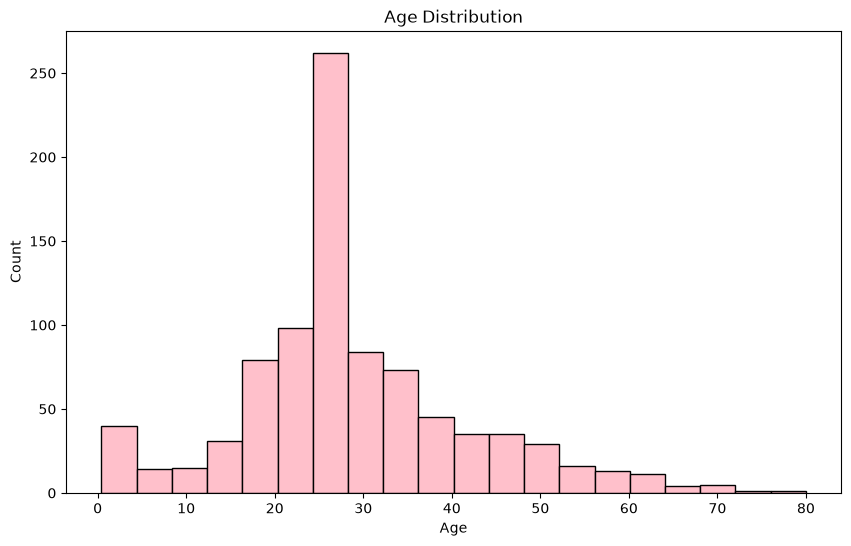

In [7]:
plt.figure(figsize=(10,6))
plt.hist(df['Age'],bins=20,color='pink',edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

### Observation

Most passengers were between 20 and 30 years old. Very young and older passengers were fewer in number.

# BoxPlot

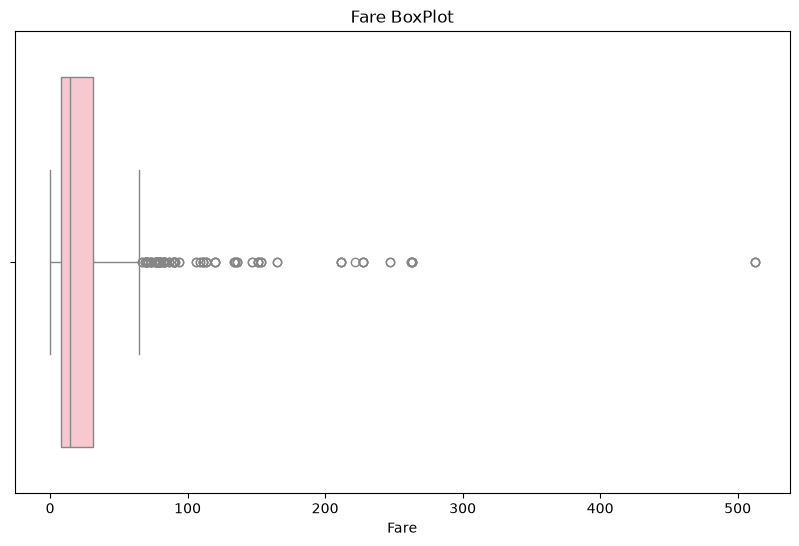

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Fare'],color='pink')
plt.title('Fare BoxPlot')
plt.show()

### Observation

Most passengers paid low fares, while only a few passengers paid very high fares. These unusually high fares are identified as outliers in the Fare column.

# BarChart

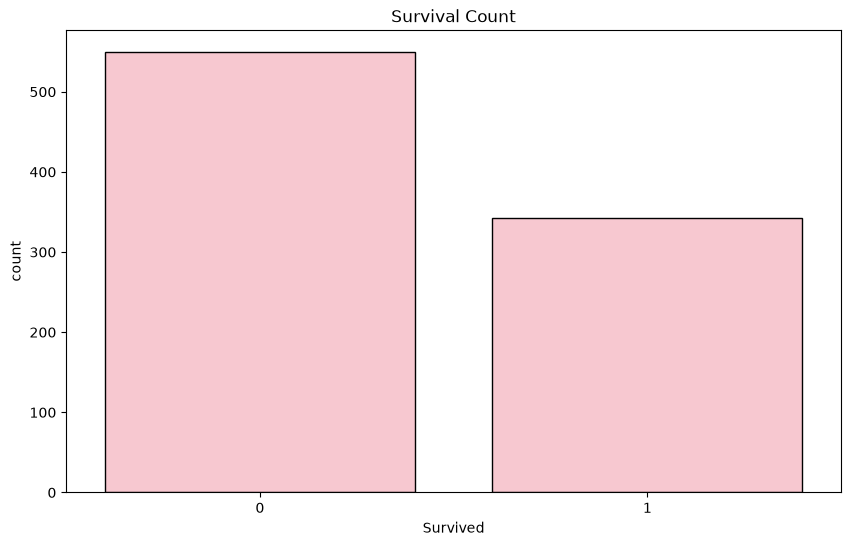

In [9]:
plt.figure(figsize=(10,6))

sns.countplot(x="Survived", data=df,color='pink',edgecolor='black')

plt.title("Survival Count")

plt.show()

### Observation
Most passengers did not survive the Titanic disaster. The number of non-survivors is higher than the number of survivors.

# Correlation Heatmap

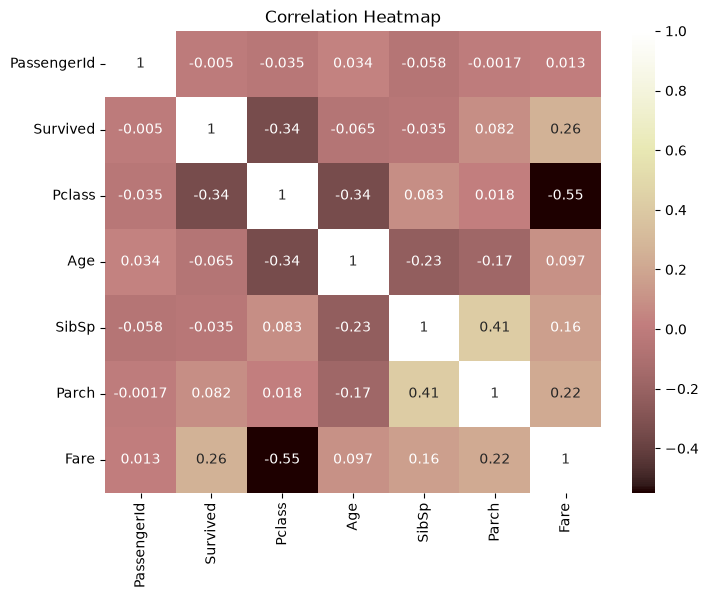

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="pink",)

plt.title("Correlation Heatmap")

plt.show()

### Observation
Most numerical features have weak correlations with survival. Fare has a positive relationship with survival, while Pclass has a negative relationship with Fare.

### Final Observation

Based on the analysis, I think **Pclass** and **Fare** have the greatest impact on survival. Passengers in higher classes generally paid higher fares and had a better chance of surviving. Age showed only a weak relationship with survival.

In [11]:
df.to_csv("Cleaned_Titanic.csv", index=False)